In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix


/home/admin1/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [7]:
# Load dataset
df = pd.read_csv("IMDB Dataset.csv")
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [11]:
# Features and target
X = data['review']
y = data['sentiment']



In [13]:
# Convert labels
y = y.map({'positive':1, 'negative':0})



In [15]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [17]:
 #Convert text to numbers
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)



In [20]:
# -------- Model 1: Logistic Regression --------
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)


/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
lr_pred = lr.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)


In [24]:
lr_acc

0.8952

In [28]:
# -------- Model 2: Naive Bayes --------
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)


MultinomialNB()

In [30]:
nb_pred = nb.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)


In [32]:
nb_acc

0.8637

In [34]:
cm_lr = confusion_matrix(y_test, lr_pred)
cm_nb = confusion_matrix(y_test, nb_pred)

print("Logistic Regression Confusion Matrix")
print(cm_lr)

print("Naive Bayes Confusion Matrix")
print(cm_nb)


Logistic Regression Confusion Matrix
[[4427  563]
 [ 485 4525]]
Naive Bayes Confusion Matrix
[[4390  600]
 [ 763 4247]]


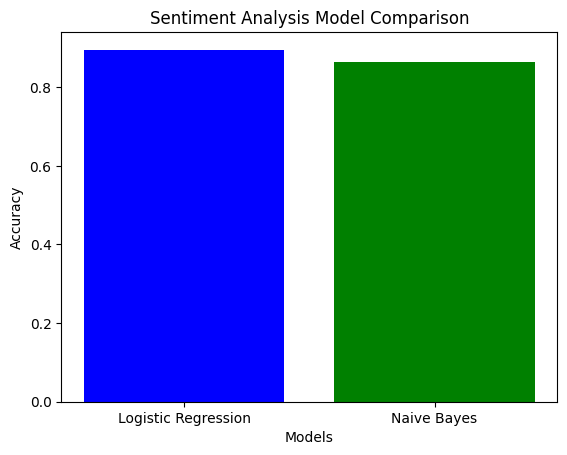

In [36]:
models = ['Logistic Regression', 'Naive Bayes']
accuracy = [lr_acc, nb_acc]

colors = ['blue','green']

plt.bar(models, accuracy, color=colors)
plt.title("Sentiment Analysis Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

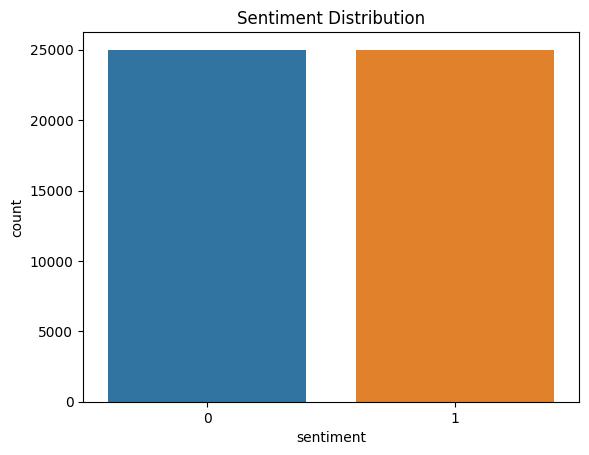

In [42]:
import seaborn as sns


sns.countplot(x=y)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()